<a href="https://colab.research.google.com/github/aarav06-bit/CS131_release/blob/master/spring_2026%20/crystal_density_classification/data_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.3 MB/s eta 0:00:00


In [26]:
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk

from scipy.ndimage import gaussian_filter
from scipy.ndimage import rotate
import os
import pandas as pd
from skimage.feature import peak_local_max

In [18]:
ELEMENTS = {

    'Au': {
        'mass': 196.97,
        'lattice_constant': 4.08,
        'structure': 'fcc'
    },

    'Al': {
        'mass': 26.98,
        'lattice_constant': 4.05,
        'structure': 'fcc'
    },

    'Fe': {
        'mass': 55.85,
        'lattice_constant': 2.87,
        'structure': 'bcc'
    },

    'Cu': {
        'mass': 63.55,
        'lattice_constant': 3.61,
        'structure': 'fcc'
    }
}

In [19]:
AVOGADRO = 6.022e23

ATOMS_PER_CELL = {
    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

def compute_density(structure, mass, lattice_constant):

    n = ATOMS_PER_CELL[structure]

    # convert angstroms to cm
    a_cm = lattice_constant * 1e-8

    volume = a_cm**3

    density = (n * mass) / (AVOGADRO * volume)

    return density

In [27]:
def generate_crystal_image(
    element='Au',
    repetitions=(8,8,4),
    grid_size=128,
    sigma=2,
    noise_level=0.01,
    rotation_angle=0
):

    info = ELEMENTS[element]

    structure = info['structure']
    lattice_constant = info['lattice_constant']
    mass = info['mass']

    # Create crystal
    atoms = bulk(
        element,
        structure,
        a=lattice_constant
    )

    atoms = atoms.repeat(repetitions)

    # Atomic positions
    positions = atoms.get_positions()

    x = positions[:,0]
    y = positions[:,1]

    # Normalize coordinates
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Create image
    image = np.zeros((grid_size, grid_size))

    x_pix = (x_norm * (grid_size - 1)).astype(int)
    y_pix = (y_norm * (grid_size - 1)).astype(int)

    # Place atoms
    for xp, yp in zip(x_pix, y_pix):
        image[yp, xp] += 1

    # Gaussian blur
    image = gaussian_filter(image, sigma=sigma)

    # Rotate image
    image = rotate(
        image,
        angle=rotation_angle,
        reshape=False
    )

    # Add Gaussian noise
    noise = np.random.normal(
        0,
        noise_level,
        image.shape
    )

    image = image + noise

    # Normalize image
    image = image - image.min()
    image = image / image.max()

    # Compute density
    density = compute_density(
        structure,
        mass,
        lattice_constant
    )

    metadata = {
        'element': element,
        'structure': structure,
        'density': density
    }

    return image, metadata

{'element': 'Au', 'structure': 'fcc', 'density': 19.263661391121232}


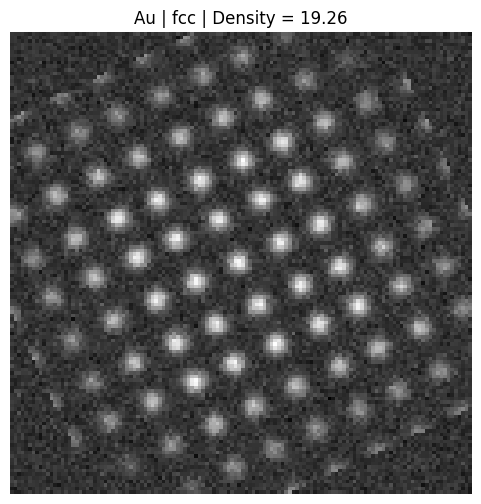

In [28]:
image, metadata = generate_crystal_image(
    element='Au',
    rotation_angle=25
)

print(metadata)

plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')

plt.title(
    f"{metadata['element']} | "
    f"{metadata['structure']} | "
    f"Density = {metadata['density']:.2f}"
)

plt.axis('off')

plt.show()

In [11]:

# Create folders
os.makedirs("dataset/images", exist_ok=True)

# Metadata storage
metadata_list = []

sample_id = 0

elements = ['Au', 'Al', 'Fe', 'Cu']

# Generate dataset
for element in elements:

    for rotation in range(0, 180, 15):

        for noise_level in [0.005, 0.01, 0.02]:

            image, metadata = generate_crystal_image(
                element=element,
                rotation_angle=rotation,
                noise_level=noise_level
            )

            filename = f"sample_{sample_id:04d}.npy"

            # Save image
            np.save(
                f"dataset/images/{filename}",
                image
            )

            # Store metadata
            metadata_list.append({
                'filename': filename,
                'element': metadata['element'],
                'structure': metadata['structure'],
                'density': metadata['density']
            })

            sample_id += 1

# Save metadata CSV
metadata_df = pd.DataFrame(metadata_list)

metadata_df.to_csv(
    "dataset/metadata.csv",
    index=False
)

print("Dataset generation complete.")
print(f"Total samples: {sample_id}")

Dataset generation complete.
Total samples: 144


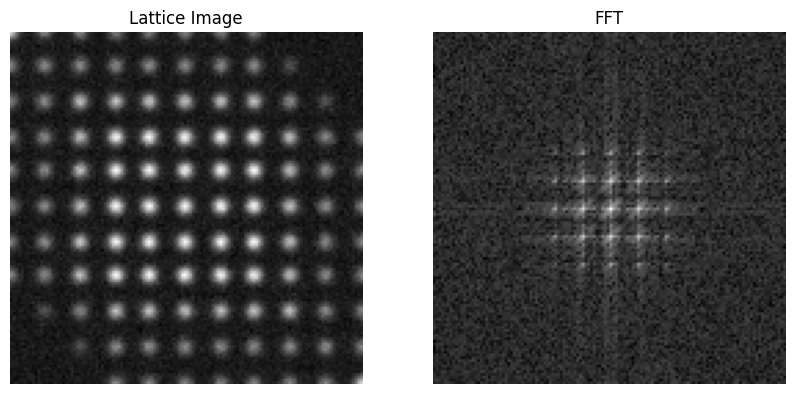

In [13]:
sample = np.load("dataset/images/sample_0000.npy")

fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

magnitude = np.log(np.abs(fft) + 1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(sample, cmap='gray')

plt.title("Lattice Image")

plt.axis('off')

plt.subplot(1,2,2)

plt.imshow(magnitude, cmap='gray')

plt.title("FFT")

plt.axis('off')

plt.show()

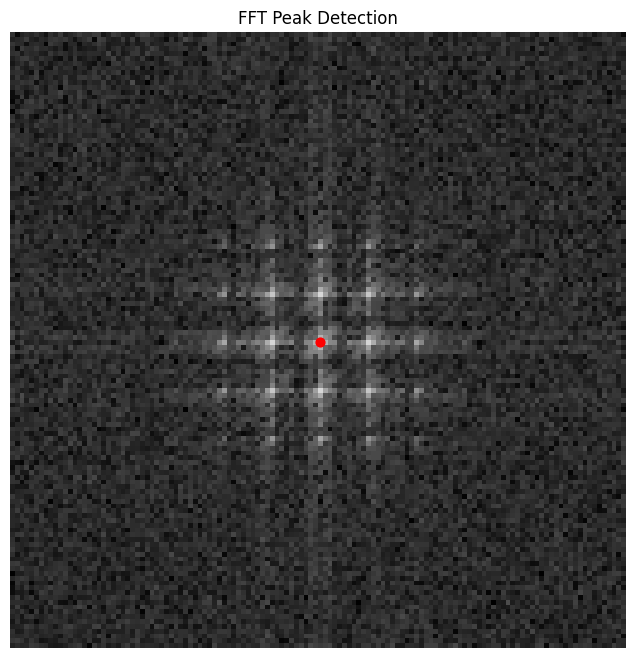

In [16]:
sample = np.load("dataset/images/sample_0000.npy")

# Compute FFT
fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

magnitude = np.log(np.abs(fft) + 1)

# Detect peaks
coordinates = peak_local_max(
    magnitude,
    min_distance=10,
    threshold_abs=4
)

# Display FFT
plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')

# Overlay detected peaks
plt.scatter(
    coordinates[:,1],
    coordinates[:,0],
    c='red',
    s=40
)

plt.title("FFT Peak Detection")

plt.axis('off')

plt.show()

Detected coordinates:
[[64 64]
 [54 64]
 [74 64]
 [64 54]
 [64 74]
 [54 74]
 [74 54]
 [54 54]
 [74 74]
 [64 44]
 [64 84]
 [44 64]
 [84 64]
 [54 84]
 [74 44]
 [44 74]
 [84 54]
 [44 54]
 [84 74]
 [54 44]]

Peak distances:
[10.         10.         10.         10.         14.14213562 14.14213562
 14.14213562 14.14213562 20.         20.         20.         20.
 22.36067977 22.36067977 22.36067977 22.36067977 22.36067977 22.36067977
 22.36067977]


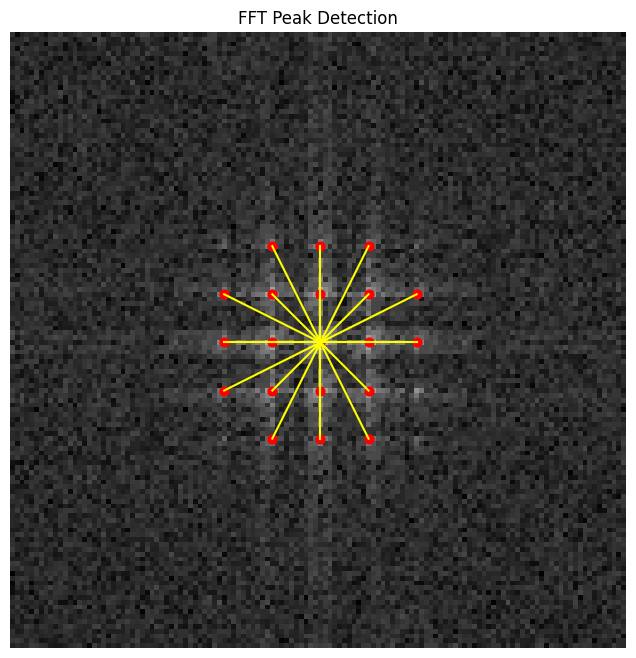

In [39]:
from skimage.feature import peak_local_max

# Load sample image
sample = np.load("dataset/images/sample_0000.npy")

# Compute FFT
fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

# FFT magnitude
magnitude = np.log(np.abs(fft) + 1)

# Detect FFT peaks
coordinates = peak_local_max(
    magnitude,
    min_distance=3,
    threshold_abs=1.5,
    num_peaks=20
)

print("Detected coordinates:")
print(coordinates)

# FFT center
center_y = magnitude.shape[0] // 2
center_x = magnitude.shape[1] // 2

# Compute distances from center
distances = []

for coord in coordinates:

    y, x = coord

    # Skip center peak
    if abs(x - center_x) < 5 and abs(y - center_y) < 5:
        continue

    distance = np.sqrt(
        (x - center_x)**2 +
        (y - center_y)**2
    )

    distances.append(distance)

distances = np.array(distances)

print("\nPeak distances:")
print(distances)

# Visualize FFT peaks
plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')

plt.scatter(
    coordinates[:,1],
    coordinates[:,0],
    c='red',
    s=40
)

# Draw lines from center
for coord in coordinates:

    y, x = coord

    plt.plot(
        [center_x, x],
        [center_y, y],
        'yellow'
    )

plt.title("FFT Peak Detection")

plt.axis('off')

plt.show()

In [40]:
# Fourier feature extraction

mean_distance = np.mean(distances)

std_distance = np.std(distances)

min_distance = np.min(distances)

max_distance = np.max(distances)

num_peaks = len(distances)

print("Mean distance:", mean_distance)

print("Std distance:", std_distance)

print("Min distance:", min_distance)

print("Max distance:", max_distance)

print("Number of peaks:", num_peaks)

Mean distance: 17.53122636420574
Std distance: 4.922910677170428
Min distance: 10.0
Max distance: 22.360679774997898
Number of peaks: 19


In [41]:
feature_data = []

for idx in range(len(metadata_df)):

    # Load image
    filename = metadata_df.iloc[idx]['filename']

    density = metadata_df.iloc[idx]['density']

    image = np.load(
        f"dataset/images/{filename}"
    )

    # Compute FFT
    fft = np.fft.fftshift(
        np.fft.fft2(image)
    )

    magnitude = np.log(np.abs(fft) + 1)

    # Detect peaks
    coordinates = peak_local_max(
        magnitude,
        min_distance=3,
        threshold_abs=1.5,
        num_peaks=20
    )

    # FFT center
    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2

    distances = []

    for coord in coordinates:

        y, x = coord

        # Skip center peak
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue

        distance = np.sqrt(
            (x - center_x)**2 +
            (y - center_y)**2
        )

        distances.append(distance)

    distances = np.array(distances)

    # Skip images with no peaks
    if len(distances) == 0:
        continue

    # Feature extraction
    mean_distance = np.mean(distances)

    std_distance = np.std(distances)

    min_distance = np.min(distances)

    max_distance = np.max(distances)

    num_peaks = len(distances)

    # Store features
    feature_data.append({

        'mean_distance': mean_distance,

        'std_distance': std_distance,

        'min_distance': min_distance,

        'max_distance': max_distance,

        'num_peaks': num_peaks,

        'density': density
    })

# Convert to dataframe
features_df = pd.DataFrame(feature_data)

print(features_df.head())

   mean_distance  std_distance  min_distance  max_distance  num_peaks  \
0      17.531226      4.922911     10.000000     22.360680         19   
1      17.531226      4.922911     10.000000     22.360680         19   
2      17.531226      4.922911     10.000000     22.360680         19   
3      17.674973      4.916735     10.440307     22.671568         19   
4      17.787480      4.976288     10.440307     22.671568         19   

     density  
0  19.263661  
1  19.263661  
2  19.263661  
3  19.263661  
4  19.263661  


In [42]:
from sklearn.model_selection import train_test_split

# Input features
X = features_df[[
    'mean_distance',
    'std_distance',
    'min_distance',
    'max_distance',
    'num_peaks'
]]

# Target labels
y = features_df['density']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 115
Testing samples: 29


In [43]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print(predictions[:10])

[11.26772995 10.88080412  8.19687741  8.6898133  10.88080412  9.89958922
 10.0601032  10.14672935 10.0601032  10.88080412]


In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Compute metrics
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

print("RMSE:", rmse)

print("R^2 Score:", r2)

Mean Absolute Error: 5.022620753121147
RMSE: 6.197398369332411
R^2 Score: 0.029478308306664647


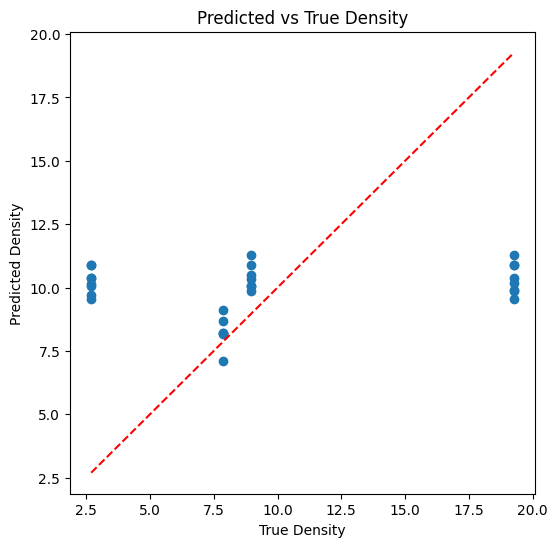

In [45]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("True Density")

plt.ylabel("Predicted Density")

plt.title("Predicted vs True Density")

# Ideal prediction line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.show()

In [29]:
!pip install torch torchvision

In [30]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import models

import pandas as pd

In [31]:
class CrystalDataset(Dataset):

    def __init__(self, metadata_path, image_dir):

        self.metadata = pd.read_csv(metadata_path)

        self.image_dir = image_dir

    def __len__(self):

        return len(self.metadata)

    def __getitem__(self, idx):

        row = self.metadata.iloc[idx]

        filename = row['filename']

        density = row['density']

        # Load image
        image = np.load(
            f"{self.image_dir}/{filename}"
        )

        # Convert to tensor
        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        # Add channel dimension
        image = image.unsqueeze(0)

        # Convert density to tensor
        density = torch.tensor(
            density,
            dtype=torch.float32
        )

        return image, density

In [33]:
dataset = CrystalDataset(
    metadata_path="dataset/metadata.csv",
    image_dir="dataset/images"
)

print("Dataset size:", len(dataset))

image, density = dataset[0]

print("Image shape:", image.shape)

print("Density:", density)

Dataset size: 144
Image shape: torch.Size([1, 128, 128])
Density: tensor(19.2637)


In [34]:
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

In [35]:
images, densities = next(iter(dataloader))

print(images.shape)

print(densities.shape)

torch.Size([16, 1, 128, 128])
torch.Size([16])
